# Feature relationships

In [1]:
import importlib
import src.data
importlib.reload(src.data)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing_data import prepare_training_data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
from src.data import load_raw_tables, prepare_delivery_events, build_master_df, add_engineering_features

In [3]:
base_path = r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1"
tables = load_raw_tables(base_path)
delivery_events = prepare_delivery_events(tables["delivery_events"])
df = build_master_df(
    delivery_events,
    tables["trips"],
    tables["loads"],
    tables["drivers"],
    tables["trucks"],
    tables["routes"],
    tables["customers"]
)
df = add_engineering_features(df)

In [4]:
df

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,...,typical_transit_days,customer_type,month,truck_age_at_event,distance_deviation,is_home_terminal,detention_risk_index,efficiency_ratio,revenue_density,is_winter
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,...,2,Spot,1,7.0,43,0,1051.0,0.893750,0.158779,1
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,...,2,Spot,1,7.0,43,0,1897.0,0.893750,0.158779,1
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,...,1,Spot,1,7.0,-4,0,1457.0,0.687500,0.044106,1
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,...,1,Spot,1,7.0,-4,0,2246.0,0.687500,0.044106,1
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,...,4,Spot,1,4.0,177,0,2166.0,1.480000,0.201464,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170815,EVT00170816,LOAD00085408,TRIP00085408,Delivery,FAC00045,2025-01-01 17:57:42.158981,2025-01-01 15:19:00.254154,126,False,Portland,...,2,Contract,1,9.0,4,0,2526.0,0.707000,0.314411,1
170816,EVT00170817,LOAD00085409,TRIP00085409,Pickup,FAC00025,2024-12-31 13:00:00.000000,2024-12-31 16:37:42.056974,13,False,Philadelphia,...,4,Dedicated,12,8.0,29,0,2123.0,0.737778,0.184528,1
170817,EVT00170818,LOAD00085409,TRIP00085409,Delivery,FAC00001,2025-01-02 16:31:42.056974,2025-01-02 21:15:48.779380,81,False,Seattle,...,4,Dedicated,1,9.0,29,0,1160.0,0.664000,0.184528,1
170818,EVT00170819,LOAD00085410,TRIP00085410,Pickup,FAC00027,2024-12-31 06:00:00.000000,2024-12-31 05:30:59.579843,48,True,Dallas,...,2,Dedicated,12,9.0,40,0,1319.0,0.682000,0.388001,1


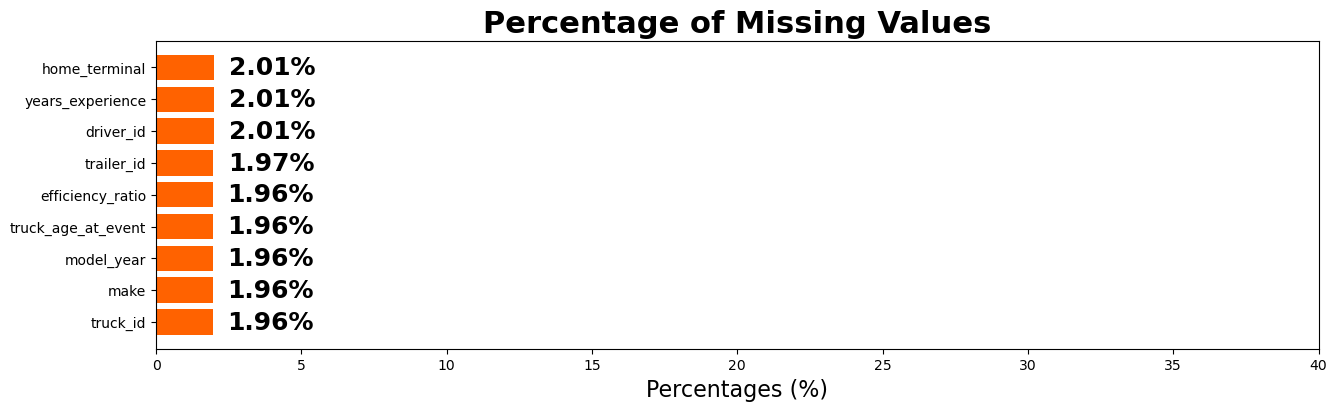

In [5]:
# Calculating the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)

# Plot the barh chart
fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color='#ff6200')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

In [6]:
# Extracting rows with missing values in 'CustomerID' or 'Description' columns
df[df['is_home_terminal'].isnull() | df['years_experience'].isnull()| df['efficiency_ratio'].isnull()| df['truck_age_at_event'].isnull()]

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,...,typical_transit_days,customer_type,month,truck_age_at_event,distance_deviation,is_home_terminal,detention_risk_index,efficiency_ratio,revenue_density,is_winter
132,EVT00000133,LOAD00000067,TRIP00000067,Pickup,FAC00009,2022-01-01 11:00:00.000000,2022-01-01 14:10:03.426897,96,False,Columbus,...,3,Dedicated,1,6.0,164,0,4062.0,0.812857,0.155007,1
133,EVT00000134,LOAD00000067,TRIP00000067,Delivery,FAC00030,2022-01-03 06:10:03.426897,2022-01-03 05:15:42.502952,158,True,Los Angeles,...,3,Dedicated,1,6.0,164,0,2050.0,0.812857,0.155007,1
138,EVT00000139,LOAD00000070,TRIP00000070,Pickup,FAC00028,2022-01-01 08:00:00.000000,2022-01-01 10:14:01.149459,52,False,Phoenix,...,1,Contract,1,NaN,38,0,2488.0,NaN,0.032773,1
139,EVT00000140,LOAD00000070,TRIP00000070,Delivery,FAC00003,2022-01-02 00:26:01.149459,2022-01-02 03:32:28.357242,211,False,Denver,...,1,Contract,1,NaN,38,0,1287.0,NaN,0.032773,1
146,EVT00000147,LOAD00000074,TRIP00000074,Pickup,FAC00005,2022-01-02 07:00:00.000000,2022-01-02 08:49:00.625747,0,True,Philadelphia,...,4,Dedicated,1,NaN,208,0,2616.0,NaN,0.246600,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170479,EVT00170480,LOAD00085240,TRIP00085240,Delivery,FAC00003,2024-12-30 08:12:11.270442,2024-12-30 12:24:14.755622,67,False,Charlotte,...,1,Spot,12,9.0,38,0,4098.0,0.728000,0.188906,1
170496,EVT00170497,LOAD00085249,TRIP00085249,Pickup,FAC00045,2024-12-30 11:00:00.000000,2024-12-30 14:47:45.266716,57,False,Minneapolis,...,3,Contract,12,9.0,0,0,2541.0,0.663000,0.138465,1
170497,EVT00170498,LOAD00085249,TRIP00085249,Delivery,FAC00027,2024-12-31 19:11:45.266716,2024-12-31 17:20:31.512351,51,True,Los Angeles,...,3,Contract,12,9.0,0,0,3238.0,0.663000,0.138465,1
170730,EVT00170731,LOAD00085366,TRIP00085366,Pickup,FAC00021,2024-12-31 08:00:00.000000,2024-12-31 10:07:47.158529,128,False,Philadelphia,...,1,Contract,12,9.0,1,0,2288.0,0.594000,0.006914,1


In [7]:
# Removing rows with missing values in 'CustomerID' and 'Description' columns
df = df.dropna(subset=['is_home_terminal', 'years_experience','efficiency_ratio','truck_age_at_event'])
df.head()

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,...,typical_transit_days,customer_type,month,truck_age_at_event,distance_deviation,is_home_terminal,detention_risk_index,efficiency_ratio,revenue_density,is_winter
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,...,2,Spot,1,7.0,43,0,1051.0,0.89375,0.158779,1
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,...,2,Spot,1,7.0,43,0,1897.0,0.89375,0.158779,1
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,...,1,Spot,1,7.0,-4,0,1457.0,0.68750,0.044106,1
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,...,1,Spot,1,7.0,-4,0,2246.0,0.68750,0.044106,1
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,...,4,Spot,1,4.0,177,0,2166.0,1.48000,0.201464,1


In [8]:
# Final Column Selection (The Optimized List)
final_columns = [
    'on_time_flag', 
    'location_state'
    'facility_congestion_score', 
    'facility_detention_avg',
    'hour_of_day', 
    'day_of_week', 
    'event_type',
    'booking_type',
    'weight_lbs', 
    'pieces',
    'revenue',
    'load_type',
    'years_experience', 
    'truck_age_at_event',
    'average_mpg', 
    'idle_time_hours',
    'distance_deviation',
    'is_home_terminal', 
    'detention_risk_index', 
    'efficiency_ratio', 
    'revenue_density',
    'is_winter'
]

In [9]:
# Separate Features and Target
categorical_cols = ['day_of_week', 'event_type', 'booking_type', 'load_type','location_state']
numeric_cols = [
    'facility_congestion_score', 'facility_detention_avg', 'hour_of_day', 
    'weight_lbs', 'pieces', 'revenue', 'years_experience', 
    'truck_age_at_event', 'average_mpg', 'idle_time_hours', 'distance_deviation',
    'is_home_terminal', 'detention_risk_index', 'efficiency_ratio', 'revenue_density','is_winter'
]
target = 'on_time_flag'

In [10]:
# Create df for model training
df_model = df[categorical_cols + numeric_cols + [target]].copy()

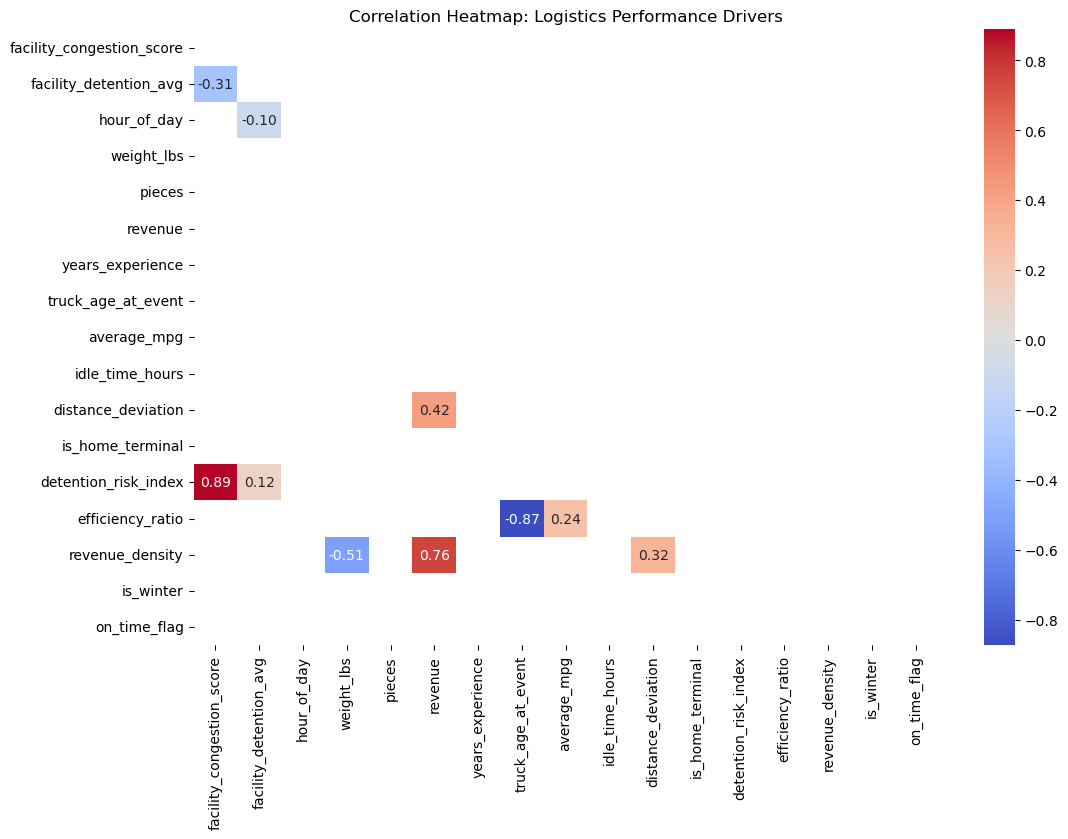

In [11]:
# HEATMAP: Correlation of Numeric Features
plt.figure(figsize=(12, 8))
correlation_matrix_n = df_model[numeric_cols + [target]].corr()
corr_filtered = correlation_matrix_n.copy()
corr_filtered[(corr_filtered > -0.1) & (corr_filtered < 0.1)] = np.nan
# create upper-triangle mask
mask = np.triu(np.ones_like(correlation_matrix_n, dtype=bool))
sns.heatmap(corr_filtered, annot=True, cmap='coolwarm', fmt=".2f", mask=mask,)
plt.title('Correlation Heatmap: Logistics Performance Drivers')
plt.show() # Or plt.savefig('heatmap.png')

In [12]:
# ONE-HOT ENCODING to convertstext categories into 0/1 columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

dummy_cols = [col for col in df_encoded.columns if any(col.startswith(cat + "_") for cat in categorical_cols)]

correlation_matrix_c = df_encoded[dummy_cols + [target]].corr()

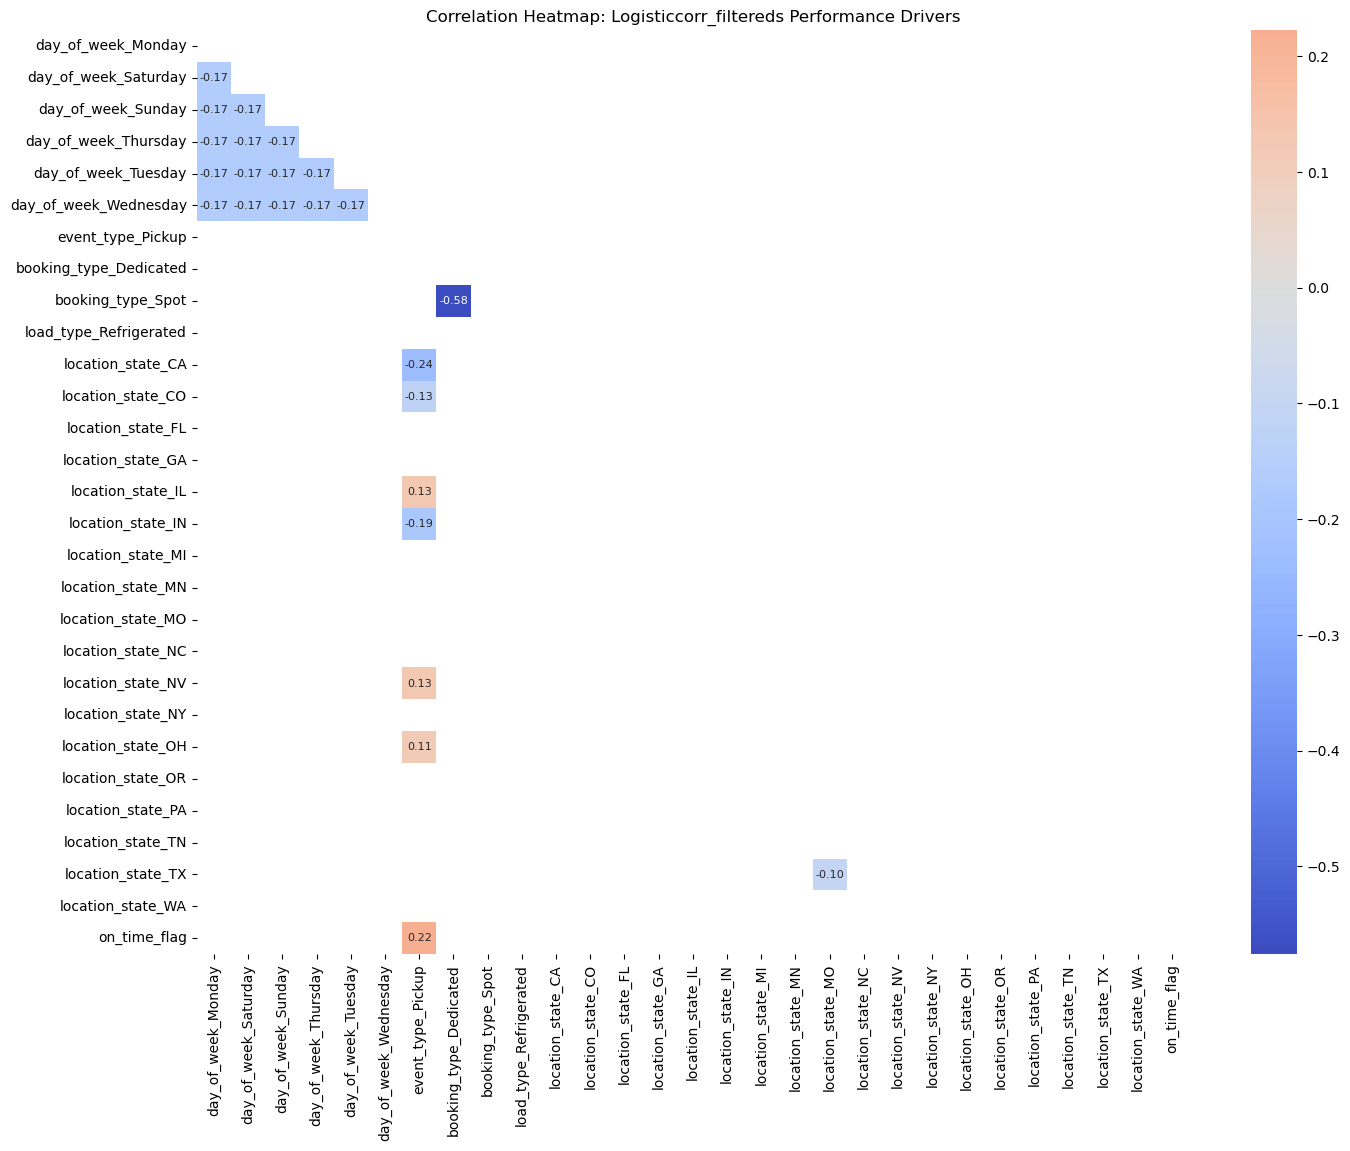

In [13]:
# HEATMAP: Correlation of Numeric Features
plt.figure(figsize=(16,12))
correlation_matrix_c = df_encoded[dummy_cols + [target]].corr()
corr_filtered = correlation_matrix_c.copy()
# hide weak correlations
corr_filtered[(corr_filtered > -0.1) & (corr_filtered < 0.1)] = np.nan
# create upper-triangle mask
mask = np.triu(np.ones_like(corr_filtered, dtype=bool))
sns.heatmap(corr_filtered, annot=True, fmt=".2f",
            annot_kws={"size":8},cmap='coolwarm', center=0,mask=mask)
plt.title('Correlation Heatmap: Logisticcorr_filtereds Performance Drivers')
plt.show() # Or plt.savefig('heatmap.png')

<Axes: >

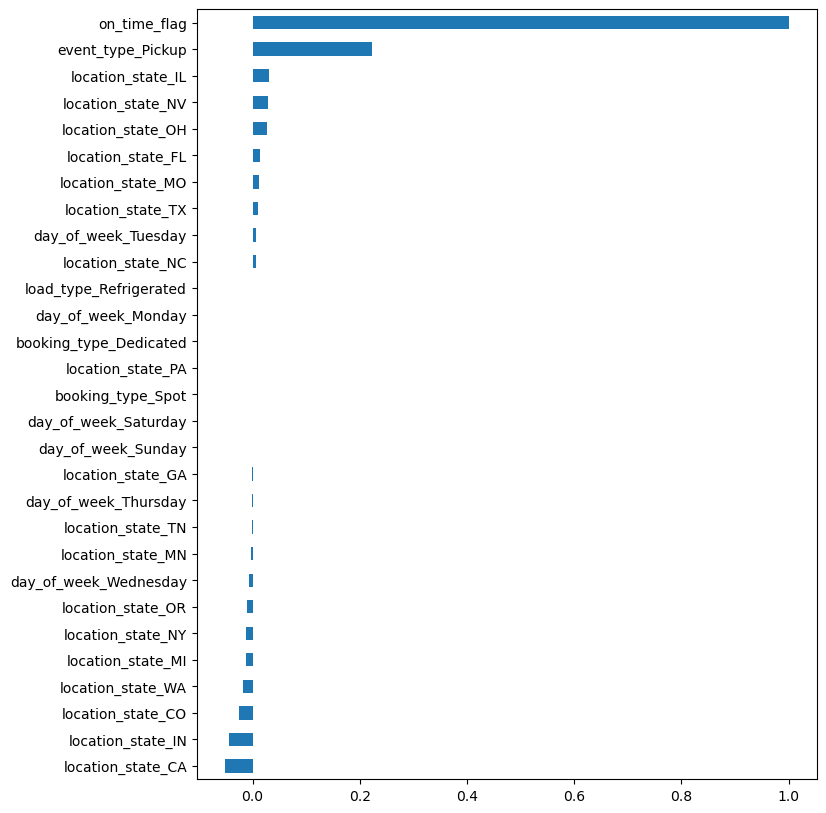

In [14]:
correlation_matrix_c['on_time_flag'].sort_values().plot.barh(figsize=(8,10))

In [15]:
from sklearn.decomposition import PCA


In [25]:
X_train_scaled, X_test_scaled, y_train, y_test, imputer, scaler = prepare_training_data(
    df_encoded, target
)

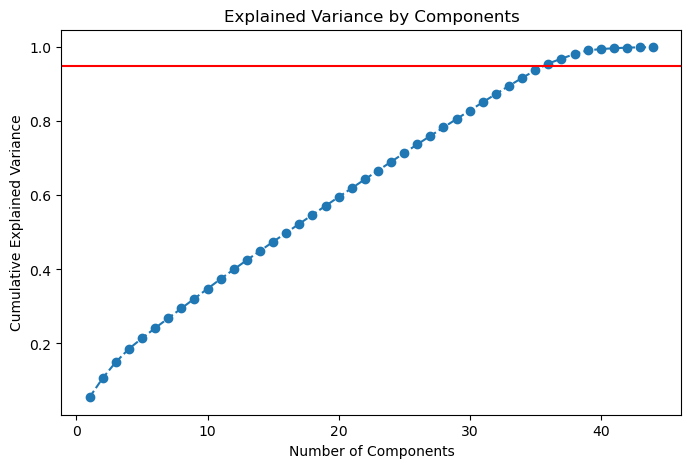

Original feature count: 44
Reduced feature count: 36


In [17]:
# 2. Apply PCA
# We start by not limiting components to see how much variance they explain
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

# 3. Determine how many components to keep (The "Scree Plot")
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(exp_var_cumul) + 1), exp_var_cumul, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

# 4. Re-run PCA with the chosen number of components (e.g., to keep 95% variance)
pca_final = PCA(n_components=0.95)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Reduced feature count: {X_train_pca.shape[1]}")

In [18]:
def apply_pca(X_train_scaled, X_test_scaled, n_components=0.95):
    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    return X_train_pca, X_test_pca, pca


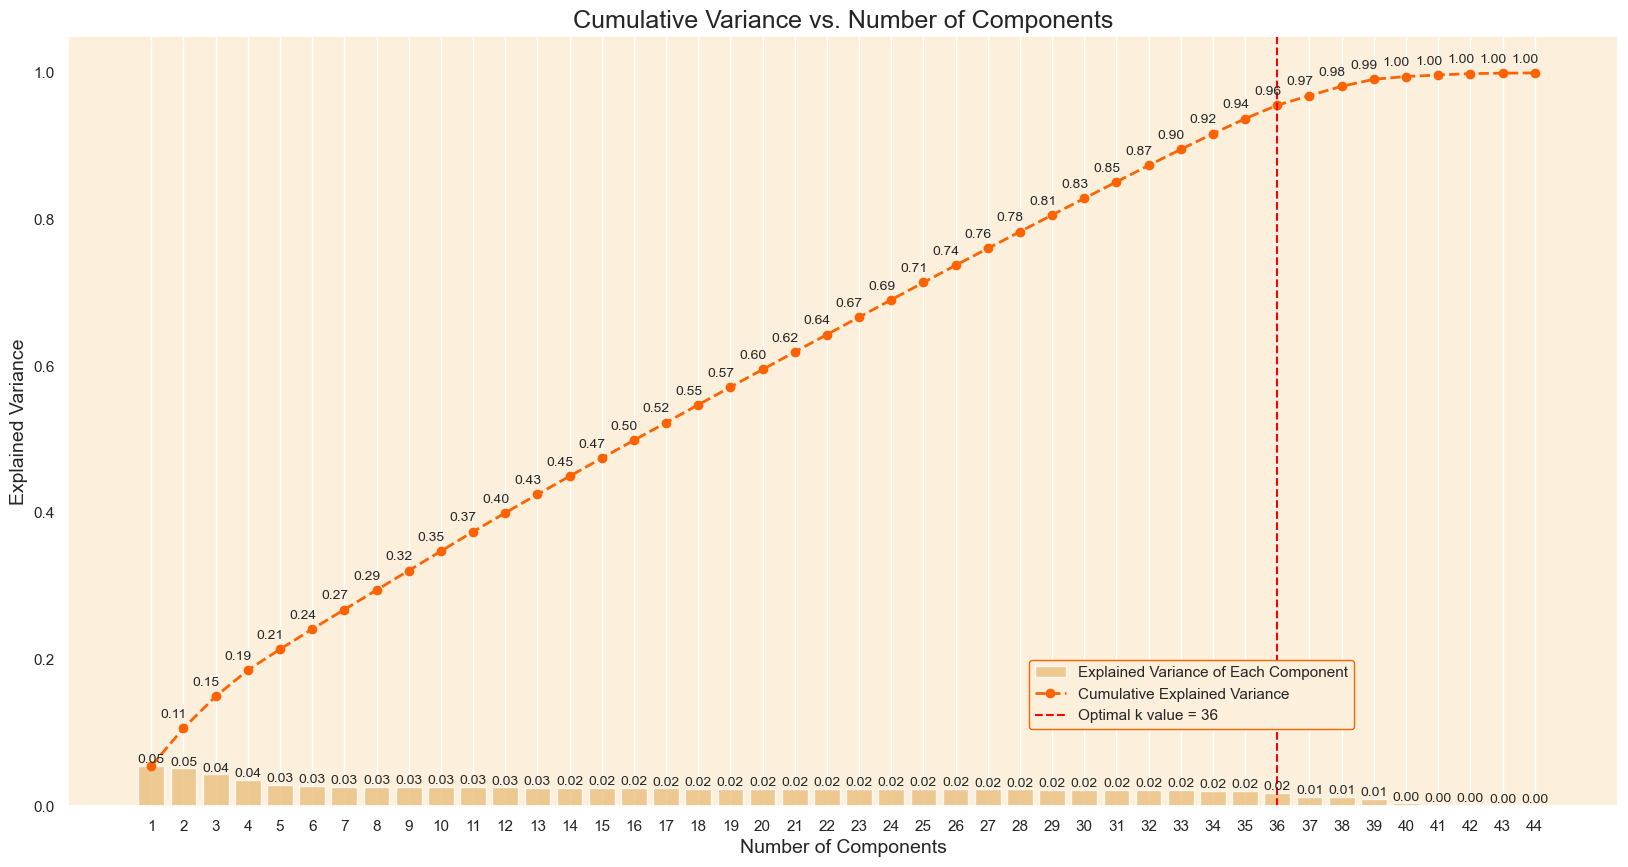

In [19]:
# Calculate the Cumulative Sum of the Explained Variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Set the optimal k value (based on our analysis, we can choose 6)
optimal_k = 36
# Set seaborn plot style
sns.set(rc={'axes.facecolor': '#fcf0dc'}, style='darkgrid')
# Plot the cumulative explained variance against the number of components
plt.figure(figsize=(20, 10))

# Bar chart for the explained variance of each component
barplot = sns.barplot(x=list(range(1, len(cumulative_explained_variance) + 1)),
                      y=explained_variance_ratio,
                      color='#fcc36d',
                      alpha=0.8)

# Line plot for the cumulative explained variance
lineplot, = plt.plot(range(0, len(cumulative_explained_variance)), cumulative_explained_variance,
                     marker='o', linestyle='--', color='#ff6200', linewidth=2)
# Plot optimal k value line
optimal_k_line = plt.axvline(optimal_k - 1, color='red', linestyle='--', label=f'Optimal k value = {optimal_k}')
# Set labels and title
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Cumulative Variance vs. Number of Components', fontsize=18)

# Customize ticks and legend
plt.xticks(range(0, len(cumulative_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot, optimal_k_line],
           labels=['Explained Variance of Each Component', 'Cumulative Explained Variance', f'Optimal k value = {optimal_k}'],
           loc=(0.62, 0.1),
           frameon=True,
           framealpha=1.0,  
           edgecolor='#ff6200')
# Display the variance values for both graphs on the plots
x_offset = -0.3
y_offset = 0.01
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f"{ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)
    if i > 0:
        plt.text(i + x_offset, cum_ev_ratio + y_offset, f"{cum_ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis='both')   
plt.show()

In [27]:
# PCA scores as DataFrames
pc_columns = [f'PC{i+1}' for i in range(pca_final.n_components_)]

X_train_pca_df = pd.DataFrame(X_train_pca, columns=pc_columns, index=X_train_scaled.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pc_columns, index=X_test_scaled.index)


In [36]:
# Define a function to highlight the top 3 absolute values in each column
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color: #ffeacc' if i in top3 else '' for i in column.index]

# Create feature names since we lost them during scaling
feature_names = [f'Feature_{i+1}' for i in range(X_train_scaled.shape[1])]

# Create the PCA loadings dataframe
pc_df = pd.DataFrame(
    pca_final.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_final.n_components_)],
    index=feature_names
)

pc_df.style.apply(highlight_top3, axis=0)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36
Feature_1,0.279021,0.527557,-0.003444,0.001445,0.264093,0.003100,-0.037771,-0.006193,0.009293,0.002885,0.030422,0.044644,-0.032971,-0.005364,0.001315,0.010848,-0.000662,0.012851,0.014671,-0.010473,0.002897,-0.004102,-0.009812,0.008273,-0.016434,0.020545,-0.000926,0.015767,-0.005984,0.012590,0.000241,0.020292,-0.106490,0.191644,-0.144220,-0.047593
Feature_2,-0.101276,-0.183944,0.002444,0.002556,0.473983,-0.076671,0.108605,-0.009449,0.022825,-0.000118,0.060014,-0.197008,-0.030414,-0.053936,-0.112338,0.001827,-0.155190,-0.018206,-0.083049,0.103425,0.130145,0.167435,0.021737,-0.064625,0.204144,-0.075829,0.011327,-0.022972,0.068749,-0.017203,-0.002116,-0.082065,0.195674,-0.408489,0.412731,0.098971
Feature_3,0.056845,0.124589,-0.000513,0.004177,-0.222021,0.113965,-0.048181,0.005740,-0.013575,-0.045489,-0.035487,0.401820,-0.220417,0.085510,0.039504,0.031116,-0.120434,0.007675,0.015888,-0.004441,0.023982,0.001069,0.052263,0.002521,0.039030,0.005391,-0.020566,0.005245,0.014685,-0.030509,0.045563,-0.024312,-0.229724,0.162847,0.747538,0.153583
Feature_4,-0.181580,0.101266,-0.003370,0.003310,0.070262,0.780021,0.068553,0.021274,-0.044094,-0.072493,-0.091924,-0.129795,0.034730,-0.012228,0.025932,0.055568,0.003248,-0.106463,-0.031114,0.036876,-0.032704,-0.040276,-0.006402,-0.033936,-0.002250,-0.015781,0.010720,-0.008571,-0.009169,-0.007655,0.004373,0.004402,0.019390,-0.006207,-0.033001,0.024794
Feature_5,-0.000027,0.001301,0.006524,-0.009303,-0.015256,0.010376,0.041330,-0.004159,-0.003522,0.009838,-0.004536,0.039670,0.028197,0.002430,-0.049606,-0.063564,-0.003617,-0.011493,-0.027746,0.063314,-0.004985,0.025389,-0.002440,-0.067300,-0.001077,0.021859,0.344364,0.637894,0.158057,0.130436,-0.427293,0.474599,0.005409,-0.026161,0.045520,0.005023
Feature_6,0.512485,-0.236083,0.016410,0.006411,0.001979,0.185044,0.019046,0.001222,-0.013740,-0.016274,-0.016891,-0.044431,0.010795,-0.002597,0.010584,0.024240,0.003672,-0.053255,-0.012301,0.017904,-0.011447,-0.018445,-0.005568,-0.015942,-0.001155,-0.006628,0.008187,-0.005906,-0.005900,-0.004012,-0.001398,0.003881,0.011395,-0.004434,-0.019849,0.025926
Feature_7,0.000141,-0.001310,0.001094,-0.012583,-0.000771,0.003512,-0.004073,-0.018228,0.006852,0.026280,0.013521,-0.021901,0.020115,-0.010002,0.024252,-0.006859,0.005466,-0.042063,0.001416,-0.024306,0.047070,-0.074263,-0.028276,0.056552,-0.103555,0.078719,-0.152331,0.659484,0.318884,-0.178943,0.421805,-0.437899,0.055116,0.015803,-0.026696,0.018041
Feature_8,0.011565,-0.011080,-0.680612,0.007257,-0.000124,0.001516,0.009918,0.001155,-0.001896,0.015913,0.006569,-0.009679,-0.013777,-0.010007,-0.004422,-0.002642,-0.016782,-0.022918,0.011355,0.001640,0.041623,-0.009214,0.035318,0.039639,0.008806,-0.011928,-0.150496,0.045347,-0.050527,0.102545,0.096255,0.139458,0.009660,-0.015210,0.003600,-0.001051
Feature_9,-0.007147,0.005181,0.188081,-0.004280,0.003196,0.002472,0.029159,-0.018748,0.016176,0.026395,0.005476,-0.022695,-0.042805,-0.006170,-0.009205,-0.016367,-0.045121,-0.079143,0.041213,0.003115,0.157120,-0.041931,0.113437,0.166083,0.024030,-0.046991,-0.539252,0.152993,-0.204349,0.368000,0.339598,0.478554,0.021345,-0.075769,0.008227,-0.013851
Feature_10,0.007700,-0.001936,0.003903,-0.011615,-0.015152,0.019644,-0.016267,0.024754,-0.009294,0.014567,0.014407,-0.014548,0.023315,-0.030464,0.024470,0.013504,0.016818,0.065993,-0.008102,-0.008177,-0.124660,-0.026791,-0.111219,0.023792,-0.040520,0.033435,0.113201,-0.184401,0.555113,0.736795,0.090106,-0.136150,-0.162346,-0.085818,0.010615,-0.015055
